In [17]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score


In [18]:
train = pd.read_csv(r"C:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\dataset\train.csv")
test = pd.read_csv(r"C:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\dataset\test.csv")
sample = pd.read_csv(r"C:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\dataset\sample_submission.csv")

In [19]:
cat_cols = train.select_dtypes(include="str").columns
cat_cols

Index(['health_condition', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='str')

In [20]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake'],
      dtype='str')

In [21]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [22]:
test.columns

Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type',
       'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender'],
      dtype='str')

In [23]:
# Approximately Normal Distribution -> Fill with mean value   #here column name is strating from mean but actually filling with median value# 
mean_sleep = train["sleep_duration"].median()

train['sleep_duration'] = train['sleep_duration'].fillna(mean_sleep)
test['sleep_duration'] = test['sleep_duration'].fillna(mean_sleep)
mean_hr = train['heart_rate'].median()

train['heart_rate'] = train['heart_rate'].fillna(mean_hr)
test['heart_rate'] = test['heart_rate'].fillna(mean_hr)
mean_bmi = train["bmi"].median()

train["bmi"] = train["bmi"].fillna(mean_bmi)
test["bmi"] = test["bmi"].fillna(mean_bmi)

mean_cal = train["calorie_expenditure"].median()

train["calorie_expenditure"] = train["calorie_expenditure"].fillna(mean_cal)
test["calorie_expenditure"] = test["calorie_expenditure"].fillna(mean_cal)

In [24]:
mean_step_count = train["step_count"].median()

train["step_count"] = train["step_count"].fillna(mean_cal)
test["step_count"] = test["step_count"].fillna(mean_cal)
mean_exercise_duration = train["exercise_duration"].median()

train["exercise_duration"] = train["exercise_duration"].fillna(mean_cal)
test["exercise_duration"] = test["exercise_duration"].fillna(mean_cal)
mean_water = train["water_intake"].median()

train["water_intake"] = train["water_intake"].fillna(mean_water)
test["water_intake"] = test["water_intake"].fillna(mean_water)

In [25]:

#fill with mode 
mode_diet = train["diet_type"].mode()[0]

train["diet_type"] = train["diet_type"].fillna(mode_diet)
test["diet_type"] = test["diet_type"].fillna(mode_diet)

In [26]:
train["stress_level"] = train["stress_level"].fillna('Unknown')
test["stress_level"] = test["stress_level"].fillna('Unknown')
train["sleep_quality"] = train["sleep_quality"].fillna('Unknown')
test["sleep_quality"] = test["sleep_quality"].fillna('Unknown')

In [27]:
mode_activity = train["physical_activity_level"].mode()[0]

train["physical_activity_level"] = train["physical_activity_level"].fillna(mode_activity)
test["physical_activity_level"] = test["physical_activity_level"].fillna(mode_activity)

In [28]:
mode_smoking = train["smoking_alcohol"].mode()[0]

train["smoking_alcohol"] = train["smoking_alcohol"].fillna(mode_smoking)
test["smoking_alcohol"] = test["smoking_alcohol"].fillna(mode_smoking)

In [29]:
mode_gender = train["gender"].mode()[0]

train["gender"] = train["gender"].fillna(mode_gender)
test["gender"] = test["gender"].fillna(mode_gender)

In [30]:
train["calorie_per_step"] = train["calorie_expenditure"] / train["step_count"]
test["calorie_per_step"] = test["calorie_expenditure"] / test["step_count"]

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

def categorical_vs_target(df, cat_col, target_col):
    """
    EDA for Categorical Feature vs Categorical Target
    """

    print("="*60)
    print(f"Feature : {cat_col}")
    print(f"Target  : {target_col}")
    print("="*60)

    # Missing Values
    print("\nMissing Values")
    print(f"{cat_col}: {df[cat_col].isnull().sum()}")
    print(f"{target_col}: {df[target_col].isnull().sum()}")

    # Frequency Table
    print("\nFeature Value Counts")
    print(df[cat_col].value_counts())

    # Percentage
    print("\nFeature Percentage")
    print(round(df[cat_col].value_counts(normalize=True)*100,2))

    # Contingency Table
    print("\nContingency Table")
    ct = pd.crosstab(df[cat_col], df[target_col])
    print(ct)

    # Row Percentage
    print("\nRow Percentage")
    print(round(pd.crosstab(df[cat_col], df[target_col],
                            normalize='index')*100,2))

    # Count Plot
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=cat_col, hue=target_col)
    plt.title(f"{cat_col} vs {target_col}")
    plt.xticks(rotation=45)
    plt.show()

    # Stacked Bar Chart
    ct.plot(kind='bar', stacked=True, figsize=(8,5))
    plt.title("Stacked Bar Chart")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

    # Heatmap
    plt.figure(figsize=(8,5))
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
    plt.title("Contingency Table Heatmap")
    plt.show()

    # Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(ct)

    print("\nChi-Square Test")
    print(f"Chi2 Statistic : {chi2:.4f}")
    print(f"P-value        : {p:.4f}")
    print(f"Degrees Freedom: {dof}")

    if p < 0.05:
        print("✅ Significant relationship between feature and target.")
    else:
        print("❌ No significant relationship between feature and target.")

    print("="*60)

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

def numerical_vs_target(df, num_col, target_col):
    """
    EDA for Numerical Feature vs Categorical Target
    """

    print("="*60)
    print(f"Feature : {num_col}")
    print(f"Target  : {target_col}")
    print("="*60)

    # Basic Statistics
    print("\nDescriptive Statistics by Target")
    print(df.groupby(target_col)[num_col].describe())

    # Missing Values
    print("\nMissing Values:", df[num_col].isnull().sum())

    # Boxplot
    plt.figure(figsize=(8,5))
    sns.boxplot(x=target_col, y=num_col, data=df)
    plt.title(f"{num_col} vs {target_col}")
    plt.show()

    # Violin Plot
    plt.figure(figsize=(8,5))
    sns.violinplot(x=target_col, y=num_col, data=df)
    plt.title(f"{num_col} Distribution by {target_col}")
    plt.show()

    # Histogram
    plt.figure(figsize=(8,5))
    sns.histplot(data=df, x=num_col, hue=target_col,
                 kde=True, element="step")
    plt.title(f"{num_col} Distribution")
    plt.show()

    # KDE Plot
    plt.figure(figsize=(8,5))
    for cls in df[target_col].dropna().unique():
        sns.kdeplot(df[df[target_col] == cls][num_col],
                    label=cls, fill=True)
    plt.legend()
    plt.title("KDE Plot")
    plt.show()

    # Mean Plot
    plt.figure(figsize=(8,5))
    sns.barplot(x=target_col, y=num_col, data=df,
                estimator="mean", errorbar="sd")
    plt.title("Mean with Standard Deviation")
    plt.show()

    # Statistical Test
    groups = [g[num_col].dropna() for _, g in df.groupby(target_col)]

    if len(groups) >= 2:
        try:
            anova = f_oneway(*groups)
            print("\nANOVA Test")
            print(f"F-statistic : {anova.statistic:.4f}")
            print(f"P-value     : {anova.pvalue:.4f}")
        except:
            pass

        try:
            kw = kruskal(*groups)
            print("\nKruskal-Wallis Test")
            print(f"Statistic : {kw.statistic:.4f}")
            print(f"P-value   : {kw.pvalue:.4f}")
        except:
            pass

    print("="*60)

Feature : calorie_per_step
Target  : health_condition

Descriptive Statistics by Target
                     count      mean       std       min       25%       50%  \
health_condition                                                               
at-risk           592561.0  0.389404  0.330818  0.112901  0.197291  0.263336   
fit                39803.0  0.233959  0.149445  0.116809  0.170363  0.198095   
unhealthy          57724.0  0.377687  0.321780  0.118339  0.195429  0.256604   

                       75%       max  
health_condition                      
at-risk           0.423146  2.600000  
fit               0.243705  2.303774  
unhealthy         0.404733  2.524402  

Missing Values: 0


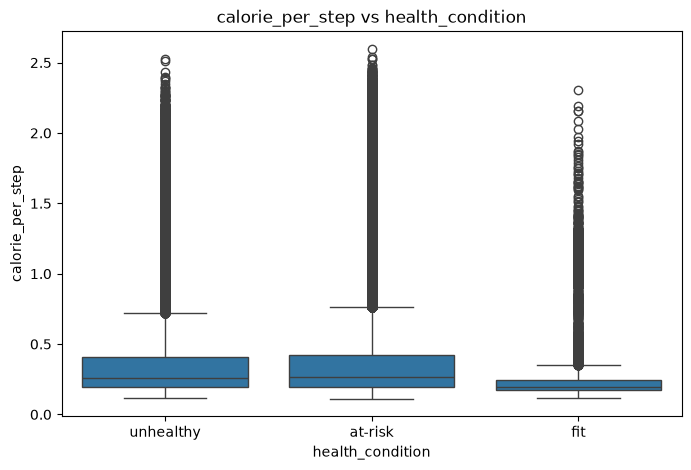

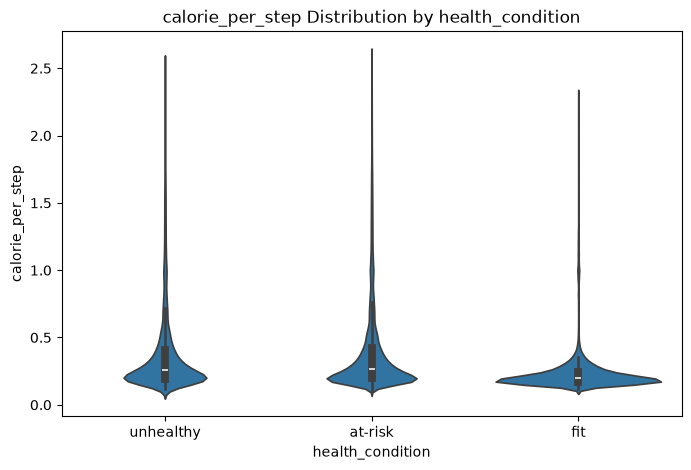

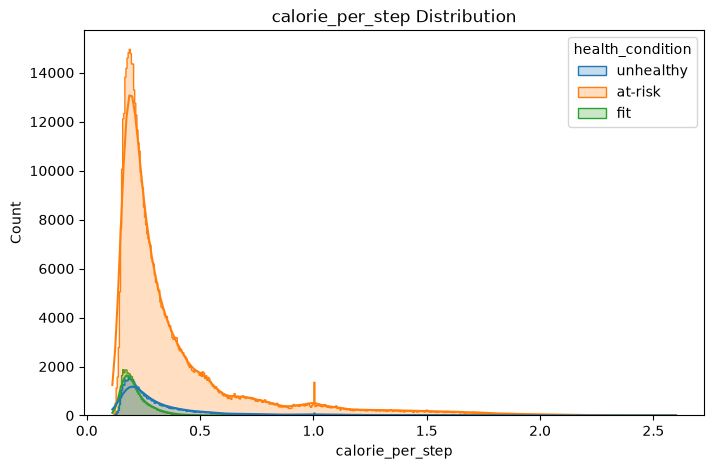

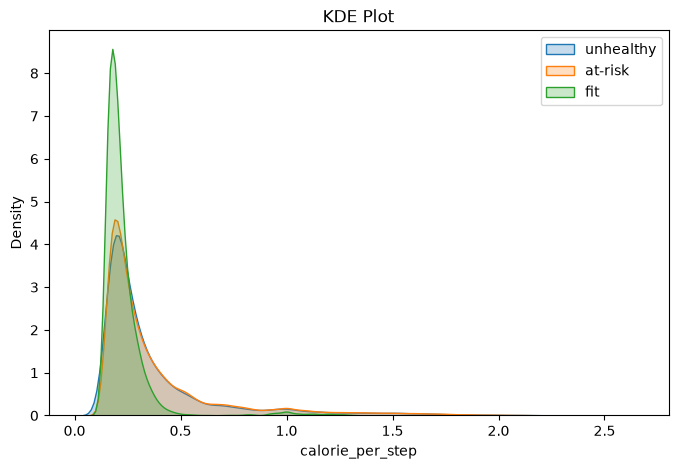

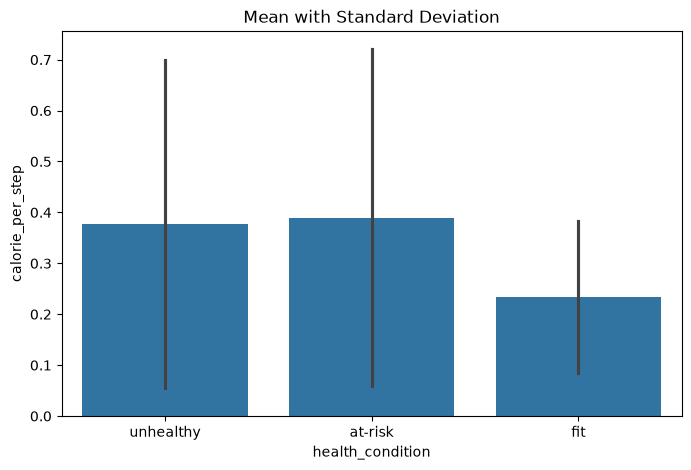


ANOVA Test
F-statistic : 4337.0077
P-value     : 0.0000

Kruskal-Wallis Test
Statistic : 18628.6952
P-value   : 0.0000


In [33]:
numerical_vs_target(train,'calorie_per_step','health_condition')

In [34]:
# BMI Category
def bmi_category(x):
    if x < 18.5:
        return "Underweight"
    elif x < 25:
        return "Normal"
    elif x < 30:
        return "Overweight"
    else:
        return "Obese"

train["bmi_category"] = train["bmi"].apply(bmi_category)
test["bmi_category"] = test["bmi"].apply(bmi_category)

Feature : bmi_category
Target  : health_condition

Missing Values
bmi_category: 0
health_condition: 0

Feature Value Counts
bmi_category
Normal         525417
Overweight     139202
Underweight     23747
Obese            1722
Name: count, dtype: int64

Feature Percentage
bmi_category
Normal         76.14
Overweight     20.17
Underweight     3.44
Obese           0.25
Name: proportion, dtype: float64

Contingency Table
health_condition  at-risk    fit  unhealthy
bmi_category                               
Normal             454595  31589      39233
Obese                 291      0       1431
Overweight         118757   3385      17060
Underweight         18918   4829          0

Row Percentage
health_condition  at-risk    fit  unhealthy
bmi_category                               
Normal              86.52   6.01       7.47
Obese               16.90   0.00      83.10
Overweight          85.31   2.43      12.26
Underweight         79.66  20.34       0.00


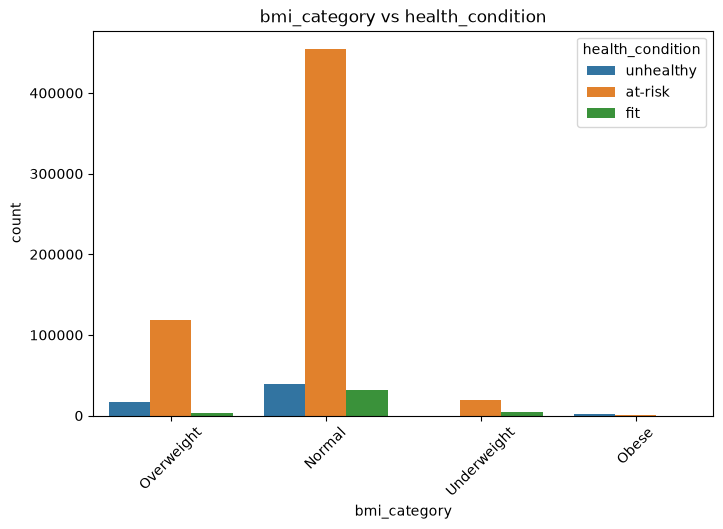

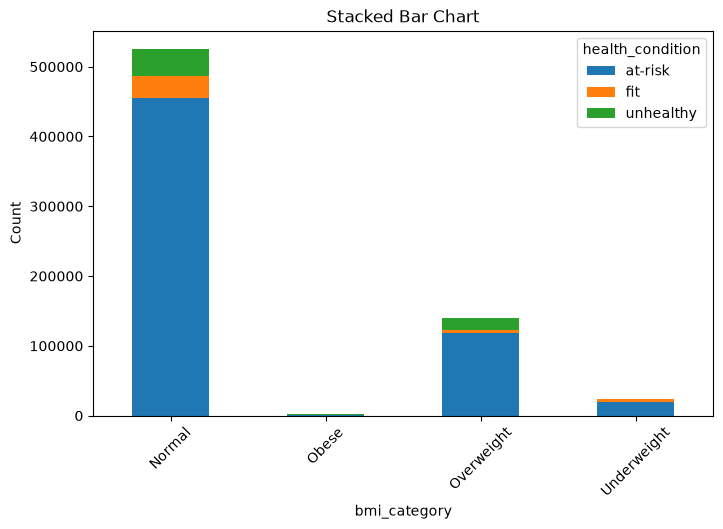

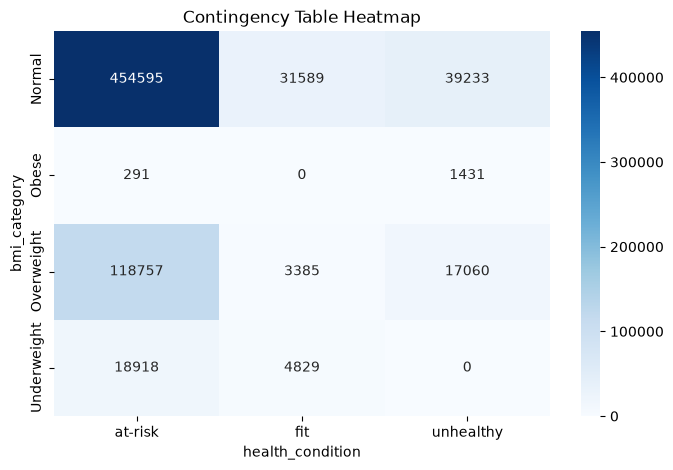


Chi-Square Test
Chi2 Statistic : 29178.5969
P-value        : 0.0000
Degrees Freedom: 6
✅ Significant relationship between feature and target.


In [35]:
categorical_vs_target(train,'bmi_category','health_condition')

In [36]:
train.shape

(690088, 17)

In [37]:
test.shape

(295753, 16)

In [38]:
from sklearn.preprocessing import OrdinalEncoder , StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix, balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [41]:
# Numerical Features
numerical_cols = [
    'sleep_duration',
    'heart_rate',
    'bmi',
    'calorie_expenditure',
    'step_count',
    'exercise_duration',
    'water_intake',
    'calorie_per_step'
]

nominal_columns = [
    'diet_type',
    'stress_level',
    'sleep_quality',
    'physical_activity_level',
    'bmi_category',
    'smoking_alcohol',
    'gender'
]

# Target Column
target_column = 'health_condition'


In [42]:
# split features and target variable
X = train.drop(columns='health_condition')
y = train['health_condition']

In [43]:
X.drop(columns='id',inplace=True)

In [44]:
test_id = test['id']

In [46]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [47]:
# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_columns
        )
    ],
    remainder="drop"
)

In [48]:
#LOGISTIC REG.
pipe = Pipeline([
    ("preprocessor", preprocessor),

    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

pipe = pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)

In [51]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

def evaluate_classification(y_true, y_pred, label_encoder=None, save_csv=False):
    """
    Complete Classification Evaluation
    
    Parameters:
    -----------
    y_true : Actual labels
    y_pred : Predicted labels
    label_encoder : LabelEncoder object (optional)
    save_csv : True to save report as CSV
    """

    print("="*70)
    print("📊 CLASSIFICATION REPORT")
    print("="*70)

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Accuracy : {acc:.4f} ({acc*100:.2f}%)\n")

    # Target names
    target_names = None
    if label_encoder is not None:
        target_names = label_encoder.classes_

    # Text Report
    print(classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4
    ))

    # DataFrame Report
    report_df = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            target_names=target_names,
            output_dict=True
        )
    ).T.round(4)

    print("="*70)
    print("📋 Classification Report DataFrame")
    print("="*70)
    print(report_df)

    if save_csv:
        report_df.to_csv("classification_report.csv", index=True)
        print("\n💾 Report saved as 'classification_report.csv'")

    return report_df

In [52]:
report_df = evaluate_classification(y_test, y_pred)

📊 CLASSIFICATION REPORT

✅ Accuracy : 0.9529 (95.29%)

              precision    recall  f1-score   support

     at-risk     0.9631    0.9832    0.9731    118512
         fit     0.8695    0.7610    0.8116      7961
   unhealthy     0.8880    0.7736    0.8269     11545

    accuracy                         0.9529    138018
   macro avg     0.9069    0.8393    0.8705    138018
weighted avg     0.9514    0.9529    0.9515    138018

📋 Classification Report DataFrame
              precision  recall  f1-score      support
at-risk          0.9631  0.9832    0.9731  118512.0000
fit              0.8695  0.7610    0.8116    7961.0000
unhealthy        0.8880  0.7736    0.8269   11545.0000
accuracy         0.9529  0.9529    0.9529       0.9529
macro avg        0.9069  0.8393    0.8705  138018.0000
weighted avg     0.9514  0.9529    0.9515  138018.0000


In [53]:
from lightgbm import LGBMClassifier


# LightGBM Pipeline
pipe = Pipeline([
    ("preprocessor", preprocessor),

    ("model", LGBMClassifier(
        n_estimators=20,
        learning_rate=0.1,
        max_depth=-1,
        random_state=42,
        n_jobs=-1
    ))
])

pipe.fit(X, y)


y_pred = pipe.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031800 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2088
[LightGBM] [Info] Number of data points in the train set: 690088, number of used features: 32
[LightGBM] [Info] Start training from score -0.152365
[LightGBM] [Info] Start training from score -2.852877
[LightGBM] [Info] Start training from score -2.481146


c:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [54]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier

def objective(trial):

    model = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators",100,500),
        learning_rate=trial.suggest_float("learning_rate",0.01,0.3,log=True),
        max_depth=trial.suggest_int("max_depth",3,15),
        num_leaves=trial.suggest_int("num_leaves",20,100),
        min_child_samples=trial.suggest_int("min_child_samples",5,50),
        subsample=trial.suggest_float("subsample",0.6,1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree",0.6,1.0),
        random_state=42
    )

    pipe = Pipeline([
        ("preprocessor1", preprocessor),
        ("model", model)
    ])

    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="balanced_accuracy",
        n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print(study.best_params)
print(study.best_value)

c:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-13 08:35:25,954] A new study created in memory with name: no-name-95263e3b-d67f-4584-a2b5-e307d1006588
[I 2026-07-13 08:36:23,223] Trial 0 finished with value: 0.8574490494542303 and parameters: {'n_estimators': 224, 'learning_rate': 0.26397521154368175, 'max_depth': 14, 'num_leaves': 92, 'min_child_samples': 19, 'subsample': 0.7844283663128434, 'colsample_bytree': 0.7733152065618173}. Best is trial 0 with value: 0.8574490494542303.
[I 2026-07-13 08:38:09,931] Trial 1 finished with value: 0.861025894452666 and parameters: {'n_estimators': 167, 'learning_rate': 0.018922964126886224, 'max_depth': 15, 'num_leaves': 46, 'min_child_samples': 26, 'subsample': 0.6298806375980226, 'colsample_bytree': 0.70

{'n_estimators': 495, 'learning_rate': 0.18718920595242777, 'max_depth': 8, 'num_leaves': 89, 'min_child_samples': 42, 'subsample': 0.6824811982784353, 'colsample_bytree': 0.6167358049741681}
0.8716098658510382


In [55]:
best_params = study.best_params

best_model = LGBMClassifier(
    **best_params,
    random_state=42,
    verbosity=-1
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

c:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [56]:
y_pred = pipe.predict(X_test)

c:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [57]:
report_df = evaluate_classification(y_test, y_pred)

📊 CLASSIFICATION REPORT

✅ Accuracy : 0.9657 (96.57%)

              precision    recall  f1-score   support

     at-risk     0.9714    0.9896    0.9804    118512
         fit     0.9254    0.8182    0.8685      7961
   unhealthy     0.9258    0.8220    0.8708     11545

    accuracy                         0.9657    138018
   macro avg     0.9409    0.8766    0.9066    138018
weighted avg     0.9649    0.9657    0.9648    138018

📋 Classification Report DataFrame
              precision  recall  f1-score      support
at-risk          0.9714  0.9896    0.9804  118512.0000
fit              0.9254  0.8182    0.8685    7961.0000
unhealthy        0.9258  0.8220    0.8708   11545.0000
accuracy         0.9657  0.9657    0.9657       0.9657
macro avg        0.9409  0.8766    0.9066  138018.0000
weighted avg     0.9649  0.9657    0.9648  138018.0000


In [58]:
y_pred = pipe.predict(test)

c:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [59]:
y_pred

array(['unhealthy', 'at-risk', 'at-risk', ..., 'at-risk', 'at-risk',
       'unhealthy'], shape=(295753,), dtype=object)

In [60]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder
label_encoder = LabelEncoder()

# Encode target column
y = label_encoder.fit_transform(y)

In [62]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train["health_condition"] = label_encoder.fit_transform(train["health_condition"])

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
from xgboost import XGBClassifier
#XGBOOST
pipe = Pipeline([
    ("preprocessor1", preprocessor),

    ("model", XGBClassifier(
        n_estimators=20,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="mlogloss"
    ))
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

In [69]:
report_df = evaluate_classification(y_test, y_pred)

📊 CLASSIFICATION REPORT

✅ Accuracy : 0.9649 (96.49%)

              precision    recall  f1-score   support

           0     0.9643    0.9964    0.9801    118512
           1     0.9530    0.7875    0.8624      7961
           2     0.9826    0.7641    0.8597     11545

    accuracy                         0.9649    138018
   macro avg     0.9666    0.8493    0.9007    138018
weighted avg     0.9652    0.9649    0.9632    138018

📋 Classification Report DataFrame
              precision  recall  f1-score      support
0                0.9643  0.9964    0.9801  118512.0000
1                0.9530  0.7875    0.8624    7961.0000
2                0.9826  0.7641    0.8597   11545.0000
accuracy         0.9649  0.9649    0.9649       0.9649
macro avg        0.9666  0.8493    0.9007  138018.0000
weighted avg     0.9652  0.9649    0.9632  138018.0000


In [70]:
y_pred = pipe.predict(test)

In [71]:
y_pred =  label_encoder.inverse_transform(y_pred)

In [72]:
import pandas as pd

result_df = pd.DataFrame({
    "id": test_id,
    "health_condition": y_pred
})

result_df.head()

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [73]:
result_df.to_csv("predictions_3.csv", index=False)

In [74]:
from xgboost import XGBClassifier

def objective(trial):

    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators",100,500),
        learning_rate=trial.suggest_float("learning_rate",0.01,0.3,log=True),
        max_depth=trial.suggest_int("max_depth",3,12),
        subsample=trial.suggest_float("subsample",0.6,1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree",0.6,1.0),
        gamma=trial.suggest_float("gamma",0,5),
        random_state=42,
        eval_metric="mlogloss"
    )

    pipe = Pipeline([
        ("preprocessor1", preprocessor),
        ("model", model)
    ])

    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="balanced_accuracy",
        n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print(study.best_params)
print(study.best_value)

[I 2026-07-13 08:59:10,543] A new study created in memory with name: no-name-a2b983d9-8030-4de0-a3ea-8b12a501e189
[I 2026-07-13 09:01:01,673] Trial 0 finished with value: 0.8636939457076692 and parameters: {'n_estimators': 275, 'learning_rate': 0.0800525131489537, 'max_depth': 7, 'subsample': 0.8772951370967152, 'colsample_bytree': 0.9770053812539892, 'gamma': 4.8056254575222805}. Best is trial 0 with value: 0.8636939457076692.
[I 2026-07-13 09:02:09,167] Trial 1 finished with value: 0.8513805018148992 and parameters: {'n_estimators': 104, 'learning_rate': 0.03209754204609199, 'max_depth': 4, 'subsample': 0.6730306435500647, 'colsample_bytree': 0.9840226978479379, 'gamma': 0.6621149324519743}. Best is trial 0 with value: 0.8636939457076692.
[I 2026-07-13 09:05:36,089] Trial 2 finished with value: 0.8638500238152543 and parameters: {'n_estimators': 358, 'learning_rate': 0.02330585346765577, 'max_depth': 9, 'subsample': 0.7240659128042723, 'colsample_bytree': 0.70150173634667, 'gamma': 4

{'n_estimators': 138, 'learning_rate': 0.11956873925016481, 'max_depth': 10, 'subsample': 0.6002408205165474, 'colsample_bytree': 0.7253977617088199, 'gamma': 0.23692252976315886}
0.8723067334134594


In [75]:
best_params = study.best_params

best_model = XGBClassifier(
    **best_params,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist"
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

In [78]:
report_df = evaluate_classification(y_test, y_pred)

📊 CLASSIFICATION REPORT

✅ Accuracy : 0.9663 (96.63%)

              precision    recall  f1-score   support

           0     0.9706    0.9910    0.9807    118512
           1     0.9310    0.8182    0.8710      7961
           2     0.9378    0.8140    0.8716     11545

    accuracy                         0.9663    138018
   macro avg     0.9465    0.8744    0.9078    138018
weighted avg     0.9656    0.9663    0.9653    138018

📋 Classification Report DataFrame
              precision  recall  f1-score      support
0                0.9706  0.9910    0.9807  118512.0000
1                0.9310  0.8182    0.8710    7961.0000
2                0.9378  0.8140    0.8716   11545.0000
accuracy         0.9663  0.9663    0.9663       0.9663
macro avg        0.9465  0.8744    0.9078  138018.0000
weighted avg     0.9656  0.9663    0.9653  138018.0000


In [79]:
y_pred = pipe.predict(test)

In [80]:
y_pred =  label_encoder.inverse_transform(y_pred)

In [81]:
import pandas as pd

result_df = pd.DataFrame({
    "id": test_id,
    "health_condition": y_pred
})

result_df.head()

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [82]:
result_df.to_csv("predictions_5.csv", index=False)

In [83]:
from catboost import CatBoostClassifier


# CatBoost Pipeline
pipe = Pipeline([
    ("preprocessor1", preprocessor),

    ("model", CatBoostClassifier(
        iterations=20,
        learning_rate=0.1,
        depth=6,
        random_state=42,
        verbose=0
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

In [84]:
report_df = evaluate_classification(y_test, y_pred)

📊 CLASSIFICATION REPORT

✅ Accuracy : 0.9624 (96.24%)

              precision    recall  f1-score   support

           0     0.9632    0.9947    0.9787    118512
           1     0.9152    0.7920    0.8492      7961
           2     0.9888    0.7481    0.8518     11545

    accuracy                         0.9624    138018
   macro avg     0.9557    0.8449    0.8932    138018
weighted avg     0.9625    0.9624    0.9606    138018

📋 Classification Report DataFrame
              precision  recall  f1-score      support
0                0.9632  0.9947    0.9787  118512.0000
1                0.9152  0.7920    0.8492    7961.0000
2                0.9888  0.7481    0.8518   11545.0000
accuracy         0.9624  0.9624    0.9624       0.9624
macro avg        0.9557  0.8449    0.8932  138018.0000
weighted avg     0.9625  0.9624    0.9606  138018.0000


In [85]:
y_pred = pipe.predict(test)

In [86]:
# Objective Function
def objective(trial):

    model = CatBoostClassifier(
        iterations=trial.suggest_int("iterations", 100, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        depth=trial.suggest_int("depth", 4, 10),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 10),
        random_strength=trial.suggest_float("random_strength", 0, 5),
        random_state=42,
        verbose=0
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="balanced_accuracy",
        n_jobs=-1
    ).mean()

    return score


# Create Study
study = optuna.create_study(direction="maximize")

# Optimize
study.optimize(objective, n_trials=10)

print("Best Score :", study.best_value)
print("Best Parameters :")
print(study.best_params)

[I 2026-07-13 09:35:57,135] A new study created in memory with name: no-name-c9995367-ea41-4928-95b4-b80d4407cede
[I 2026-07-13 09:44:16,349] Trial 0 finished with value: 0.86215221360891 and parameters: {'iterations': 405, 'learning_rate': 0.047806685045933696, 'depth': 8, 'l2_leaf_reg': 8.062120280574987, 'random_strength': 2.6763621197704355}. Best is trial 0 with value: 0.86215221360891.
[I 2026-07-13 09:46:06,682] Trial 1 finished with value: 0.8443676377804253 and parameters: {'iterations': 137, 'learning_rate': 0.014130595073756578, 'depth': 7, 'l2_leaf_reg': 1.2381637065226574, 'random_strength': 2.1692921134364003}. Best is trial 0 with value: 0.86215221360891.
[I 2026-07-13 09:48:07,696] Trial 2 finished with value: 0.856053593069801 and parameters: {'iterations': 188, 'learning_rate': 0.053985862629354425, 'depth': 5, 'l2_leaf_reg': 8.006456270254413, 'random_strength': 4.328051655741401}. Best is trial 0 with value: 0.86215221360891.
[I 2026-07-13 09:53:14,823] Trial 3 fini

Best Score : 0.8702228770003931
Best Parameters :
{'iterations': 406, 'learning_rate': 0.1872784478793385, 'depth': 8, 'l2_leaf_reg': 7.8846803402411885, 'random_strength': 4.877321051407792}


In [87]:
best_params = study.best_params

best_model = CatBoostClassifier(
    **best_params,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

In [88]:
report_df = evaluate_classification(y_test,y_pred)

📊 CLASSIFICATION REPORT

✅ Accuracy : 0.9365 (93.65%)

              precision    recall  f1-score   support

           0     0.9928    0.9337    0.9623    118512
           1     0.7101    0.9421    0.8098      7961
           2     0.6935    0.9613    0.8057     11545

    accuracy                         0.9365    138018
   macro avg     0.7988    0.9457    0.8593    138018
weighted avg     0.9515    0.9365    0.9404    138018

📋 Classification Report DataFrame
              precision  recall  f1-score      support
0                0.9928  0.9337    0.9623  118512.0000
1                0.7101  0.9421    0.8098    7961.0000
2                0.6935  0.9613    0.8057   11545.0000
accuracy         0.9365  0.9365    0.9365       0.9365
macro avg        0.7988  0.9457    0.8593  138018.0000
weighted avg     0.9515  0.9365    0.9404  138018.0000


In [89]:
y_pred = pipe.predict(test)

In [90]:
y_pred = label_encoder.inverse_transform(y_pred)

c:\Users\Yash bhungaliya\Desktop\ML\student_healthRisk\venv\Lib\site-packages\sklearn\preprocessing\_label.py:161: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [91]:
import pandas as pd

result_df = pd.DataFrame({
    "id": test_id,
    "health_condition": y_pred
})

result_df.head()

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [97]:
result_df.to_csv("predictions_final.csv", index=False)

In [99]:
import pickle

pickle.dump(pipe, open("student_health_model.pkl", "wb"))

In [100]:
import pickle

pickle.dump(label_encoder, open("label_encoder.pkl", "wb"))

In [101]:
import pickle

pickle.dump(train, open("df.pkl", "wb"))